- 삼성전자 데이터 → State/Action/Reward → MDP → Return → V/Q → Bellman/DP → MC/TD → SARSA/Q-Learning → DQN → Policy Gradient → PPO + 백테스트

## 공통 준비 코드

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pykrx import stock
from datetime import datetime

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


In [14]:

# ==========================================
# 삼성전자 주가 데이터
# ==========================================

ticker = "005930"

start_date = "20200101"
end_date = datetime.today().strftime("%Y%m%d")

df = stock.get_market_ohlcv_by_date(
    start_date,
    end_date,
    ticker
)

# 필요한 열만 사용
df = df[["시가", "고가", "저가", "종가", "거래량"]].copy()

# 일별 수익률
df["수익률"] = df["종가"].pct_change()

# 이동평균
df["MA5"] = df["종가"].rolling(5).mean()
df["MA20"] = df["종가"].rolling(20).mean()

# 변동성
df["변동성5"] = df["수익률"].rolling(5).std()

# 다음 날 수익률
df["다음날수익률"] = df["수익률"].shift(-1)

df = df.dropna()

print(df.tail())

                시가      고가      저가      종가       거래량       수익률       MA5  \
날짜                                                                         
2026-08-20  257000  273000  252500  271000  26095919  0.094949  265900.0   
2026-08-21  267000  285000  266000  281500  27746471  0.038745  268600.0   
2026-08-24  271500  272000  255000  257000  32451940 -0.087034  265100.0   
2026-08-25  249000  258000  245000  257000  21617407  0.000000  262800.0   
2026-08-26  256500  266500  255500  261500  19532523  0.017510  265600.0   

                MA20      변동성5    다음날수익률  
날짜                                        
2026-08-20  245650.0  0.066456  0.038745  
2026-08-21  246225.0  0.065249 -0.087034  
2026-08-24  246600.0  0.077646  0.000000  
2026-08-25  246750.0  0.077475  0.017510  
2026-08-26  248825.0  0.066284  0.017208  


## 1회차. 강화학습 입문

- Agent · Environment · State · Action · Reward

- 실습 목표 : 삼성전자 주식에서 강화학습의 5가지 핵심 요소를 직접 만들어봅니다.
- Agent: 투자자
- Environment: 주식시장
- State: 현재 주가 상태
- Action: 현금 / 삼성전자 보유
- Reward: 다음 날 투자수익률

In [15]:
# 최근 데이터 한 개 선택
row = df.iloc[-10]

state = {
    "종가": row["종가"],
    "MA5": row["MA5"],
    "수익률": row["수익률"]
}

print("State")
print(state)

State
{'종가': np.float64(255500.0), 'MA5': np.float64(237300.0), '수익률': np.float64(0.06680584551148216)}


- 행동 정의

In [16]:
# Action
# 0 = 현금 보유
# 1 = 삼성전자 보유

action = 1

next_return = row["다음날수익률"]

if action == 1:
    reward = next_return
else:
    reward = 0

print("Action :", action)
print("다음날 수익률 :", next_return)
print("Reward :", reward)

Action : 1
다음날 수익률 : 0.048923679060665304
Reward : 0.048923679060665304


In [17]:
# 핵심
# State
#  ↓
# Agent
#  ↓
# Action
#  ↓
# Environment
#  ↓
# Reward + Next State

In [18]:
# ① Action = 1
# Action = 1은 Agent가 삼성전자를 보유하기로 행동했다는 의미입니다.
# ② 다음날 수익률 = 0.04892
# 즉,삼성전자 주가가 다음 날 약 4.89% 상승했습니다.
# ③ Reward = 0.04892
# if action == 1:
#     reward = next_return
# else:
#     reward = 0
# Agent가 삼성전자를 보유했고 실제 삼성전자가 다음 날 4.89% 상승했기 때문에,Reward = +4.89%가 됩니다.
# 즉, 좋은 행동이었다고 보상을 받은 것입니다.
# 강화학습 관점에서 전체 흐름
# State
# 현재 삼성전자 시장상황
#        ↓
# Agent
# 투자 의사결정
#        ↓
# Action = 1
# 삼성전자 보유
#        ↓
# Environment
# 다음 날 주식시장 움직임
#        ↓
# 삼성전자 +4.89%
#        ↓
# Reward = +4.89%
#        ↓
# Agent는 이 행동이 좋았다고 학습
# 다만 1회차에서는 아직 실제로 학습한 것은 아닙니다. 
# 지금은 단순히 행동을 했을 때 Reward가 어떻게 만들어지는지를 체험한 단계입니다.

## 2회차. MDP 만들기

- State · Action · Reward · Transition
- 이번에는 연속적인 주가를 간단한 이산 상태(Discrete State)로 바꿉니다.

### 상태 정의

- 상태는 다음과 같습니다.
- State 0 = 종가 ≤ MA5 → 약세
- State 1 = 종가 > MA5 → 강세

In [19]:
def make_state(row):

    if row["종가"] > row["MA5"]:
        return 1   # 상승 상태

    else:
        return 0   # 하락 상태


df["State"] = df.apply(make_state, axis=1)

df[["종가", "MA5", "State"]].tail(10)

,종가,MA5,State
날짜,,,
2026-08-12,255500,237300.0,1
2026-08-13,268000,244800.0,1
2026-08-14,274500,253500.0,1
2026-08-18,268500,261200.0,1
2026-08-19,247500,262800.0,0
2026-08-20,271000,265900.0,1
2026-08-21,281500,268600.0,1
2026-08-24,257000,265100.0,0
2026-08-25,257000,262800.0,0


### 다음 State 생성

In [20]:
df["Next_State"] = df["State"].shift(-1)

df = df.dropna()

df[[
    "종가",
    "MA5",
    "State",
    "Next_State"
]].tail()

,종가,MA5,State,Next_State
날짜,,,,
2026-08-19,247500,262800.0,0,1.0
2026-08-20,271000,265900.0,1,1.0
2026-08-21,281500,268600.0,1,0.0
2026-08-24,257000,265100.0,0,0.0
2026-08-25,257000,262800.0,0,0.0


### Transition 관찰

In [21]:
transition = pd.crosstab(
    df["State"],
    df["Next_State"],
    normalize="index"
)

print(transition)

Next_State       0.0       1.0
State                         
0           0.738750  0.261250
1           0.257389  0.742611


- 이를 통해 현재 시장 상태 → 다음 시장 상태의 전이확률을 볼 수 있습니다.

- 오늘 삼성전자의 시장 상태(State)가 주어졌을 때, 다음 날 어떤 상태(Next State)가 될 확률이 높은가를 보여줍니다.

In [22]:
# ① 현재 State = 0인 경우
# State 0 → Next State 0 : 0.738750
# State 0 → Next State 1 : 0.261250

# 현재 삼성전자가 약세 상태라면,
# 다음 날에도 약세 상태일 확률 = 73.88%, 다음 날 강세 상태로 바뀔 확률 = 26.13%입니다.
# ==> 즉, 약세 상태가 다음 날에도 유지되는 경향이 나타났습니다.

# ② 현재 State = 1인 경우
# State 1 → Next State 0 : 0.257389
# State 1 → Next State 1 : 0.742611

# 현재 삼성전자가 강세 상태라면,
# 다음 날 약세 상태로 바뀔 확률 = 25.74%, 다음 날에도 강세 상태일 확률 = 74.26%입니다.
# ===> 역시 강세 상태가 다음 날에도 유지되는 경향이 나타납니다.

# 이것이 바로 MDP의 Transition Probability입니다.

- 2회차 결과가 다음 강화학습 개념으로 연결됩니다.
- State → Transition Probability → Reward → Value → Bellman Equation
- 즉, “현재 상태에서 행동했을 때 다음 상태가 어떻게 변하는가?”를 알게 되었으므로, 
- 이제 “그 상태가 얼마나 좋은가?”, 즉 V(s)와 Q(s,a)를 학습하는 단계로 넘어갈 수 있습니다.

## 3회차. Policy → Trajectory → Return

- 삼성전자 수익률 → Reward로 사용 → Reward들을 누적하여 Return 계산 → Return을 이용해 V와 Q를 학습이라는 흐름

- V(s), 상태가치함수: 현재 상태가 앞으로 얼마나 좋은가?
- Q(s,a), 행동가치함수: 현재 상태에서 특정 행동을 하는 것이 앞으로 얼마나 좋은가?
- 주식으로 보면 V = 지금 시장상황의 가치, Q = 지금 시장상황에서 매수·보유 같은 특정 행동의 가치입니다.

### 정책

- 이번에는 간단한 투자정책을 만듭니다.

- 종가 > MA5 → 삼성전자 보유(1)
- 종가 ≤ MA5 → 현금(0)

In [23]:
def policy(state):

    if state == 1:
        return 1     # 삼성전자 보유

    else:
        return 0     # 현금

### 행동 생성

In [24]:
df["Action"] = df["State"].apply(policy)

df[[
    "종가",
    "MA5",
    "State",
    "Action"
]].tail(10)

,종가,MA5,State,Action
날짜,,,,
2026-08-11,239500,235400.0,1,1
2026-08-12,255500,237300.0,1,1
2026-08-13,268000,244800.0,1,1
2026-08-14,274500,253500.0,1,1
2026-08-18,268500,261200.0,1,1
2026-08-19,247500,262800.0,0,0
2026-08-20,271000,265900.0,1,1
2026-08-21,281500,268600.0,1,1
2026-08-24,257000,265100.0,0,0


### Reward : 투자해서 얻은 수익률

- Agent가 삼성전자를 보유했다면 그날 발생한 투자수익률을 Reward로 사용할 수 있습니다.
- 여기서 Reward는 한 시점에서 받은 보상입니다.

In [25]:
df["Reward"] = (
    df["Action"]
    * df["다음날수익률"]
)

df[[
    "State",
    "Action",
    "다음날수익률",
    "Reward"
]].tail()

,State,Action,다음날수익률,Reward
날짜,,,,
2026-08-19,0,0,0.094949,0.000000
2026-08-20,1,1,0.038745,0.038745
2026-08-21,1,1,-0.087034,-0.087034
2026-08-24,0,0,0.000000,0.000000
2026-08-25,0,0,0.017510,0.000000


### Return 계산: 미래에 받을 Reward의 누적합--> 강화학습의 Return \(G_t\)은 앞으로 받을 Reward들을 합한 것입니다.

In [26]:
gamma = 0.99

In [27]:
# Return: $$ G_t = R_{t+1} +\gamma R_{t+2} +\gamma^2R_{t+3} +\cdots $$

In [28]:
rewards = df["Reward"].tail(20).values

G = 0

for reward in reversed(rewards):

    G = reward + gamma * G

print("Discounted Return :", G)

Discounted Return : -0.12033984729498536


In [29]:
# Discounted Return = -0.1203 → 최근 20일 동안 이 투자정책이 만들어낸 장기 누적 보상이 음수이므로, 강화학습 관점에서는 좋지 않은 결과이다.
# 그리고 이것이 다음 단계인 V와 Q로 연결됩니다.
# Return을 여러 번 관찰 → 어떤 State의 평균 Return이 높은가? = V(s) → 어떤 State에서 어떤 Action의 Return이 높은가? = Q(s,a)

## 4회차. V(s)와 Q(s,a)

### V(s) : 상태가치함수

In [30]:
- V(s), 상태가치함수: 현재 시장 상태가 앞으로 얼마나 좋은가?

Object `좋은가` not found.


In [31]:
V = df.groupby("State")["다음날수익률"].mean()

print(V)

State
0    0.001744
1    0.000755
Name: 다음날수익률, dtype: float64


- 예를들어
- State 0 → 약세일 때 평균 다음날 수익률
- State 1 → 강세일 때 평균 다음날 수익률

### Q(s,a) : 행동가치함수

- Q(s,a), 행동가치함수: 현재 상태에서 특정 행동을 하는 것이 앞으로 얼마나 좋은가?

In [32]:
# 먼저 여러 행동을 관찰하기 위해 임의 행동을 생성합니다.
np.random.seed(42)

df["Random_Action"] = np.random.choice(
    [0, 1],
    size=len(df)
)

df["Random_Reward"] = (
    df["Random_Action"]
    * df["다음날수익률"]
)

- Q값 계산:

In [33]:
Q = df.groupby(
    ["State", "Random_Action"]
)["Random_Reward"].mean()

print(Q)

State  Random_Action
0      0                0.000000
       1                0.002339
1      0                0.000000
       1                0.000347
Name: Random_Reward, dtype: float64


- Q(강세, 삼성전자 보유)
- Q(강세, 현금)
- Q(약세, 삼성전자 보유)
- Q(약세, 현금)

In [34]:
# ① State=0, Action=0 → 0
# State 0은 종가 ≤ MA5인 약세 상태입니다.
# 이때 Action=0, 즉 현금을 보유했으므로 주가가 움직여도 Reward를 0으로 정의했습니다. Q(0,0)=0 
# ② State=0, Action=1 → 0.002339
# 약세 상태에서 삼성전자를 보유했을 때 평균 Reward가 0.002339였습니다.
# 즉,약세 상태에서 삼성전자를 보유한 경우 평균적으로 약 +0.234%의 다음 날 보상이 관찰되었습니다.

# ③ State=1, Action=0 → 0
# State 1은 종가 > MA5인 강세 상태입니다.
# 하지만 현금을 보유했기 때문에 Reward는 0입니다. Q(1,0)=0 
# ④ State=1, Action=1 → 0.000347
# 강세 상태에서 삼성전자를 보유했을 때 평균 Reward는 0.000347입니다.
# 즉,강세 상태에서 삼성전자를 보유했을 때 평균적으로 약 +0.035%의 다음 날 보상이 관찰되었습니다.

# 결과가 조금 이상해 보일 수 있습니다
# 그런데 이번 결과에서는 오히려 Q(약세,보유)=0.234% > Q(강세,보유)=0.035% 입니다.
# 이것은 충분히 가능합니다. 
# 예를 들어 MA5 아래로 내려간 이후 다음 날 반등하는 효과가 데이터에 나타났을 수도 있습니다.
# 하지만 더 중요한 이유가 있습니다. 이번 실습에서는
# df["Random_Action"] = np.random.choice([0, 1], size=len(df))
# 처럼 행동을 무작위로 선택했고,
# df["Random_Reward"] = (
#     df["Random_Action"]
#     * df["다음날수익률"]
# )
# 로 단순 평균 Reward를 계산했습니다.
# 따라서 이것을 “약세일 때 삼성전자를 사는 것이 최적 전략이다”라고 결론 내리면 안 됩니다.
# 더 정확히 말하면 아직 진짜 Q는 아닙니다
# 강화학습에서 Q는 원래 현재 State에서 Action을 했을 때 앞으로 받을 Return의 기대값입니다.
#  Q(s,a)=E[G_t\mid S_t=s,A_t=a] 
# 그런데 4회차 코드에서는 이해를 쉽게 하기 위해 다음 날 Reward의 평균만 사용했습니다.
# 이번 실습의 Q는 '상태별·행동별 평균 다음 날 보상'으로 Q의 개념을 단순화한 것이다. 
# 실제 Q는 미래의 누적 보상(Return)까지 고려한다.
# 그리고 이것이 바로 5회차 Bellman Equation으로 넘어가는 이유입니다.

## 5회차. Bellman과 Dynamic Programming

- 이번에는 Bellman의 핵심 아이디어를 코드로 확인합니다.
- 현재 가치 = 현재 보상 + 할인된 미래 가치
- 먼저 상태를 3개로 늘려보겠습니다.

In [35]:
def market_state(row):

    if row["종가"] > row["MA5"] and row["MA5"] > row["MA20"]:
        return 2       # 상승

    elif row["종가"] < row["MA5"] and row["MA5"] < row["MA20"]:
        return 0       # 하락

    else:
        return 1       # 중립


df["State3"] = df.apply(
    market_state,
    axis=1
)

### Bellman Backup

- Bellman Backup: 현재의 보상(Reward)과 다음 상태의 가치(Value)를 이용해 현재 상태의 가치를 새롭게 업데이트하는 과정입니다.
- 현재 가치 ← 현재 보상 + 할인된 미래 가치

In [36]:
gamma = 0.95

V = np.zeros(3)

for _ in range(100):

    new_V = np.zeros(3)

    for s in range(3):

        temp = df[
            df["State3"] == s
        ]

        if len(temp) == 0:
            continue

        reward = temp["다음날수익률"].mean()

        next_value = V[s]

        new_V[s] = (
            reward
            + gamma * next_value
        )

    V = new_V

print("V =", V)

V = [0.03592839 0.00715854 0.03774181]


   state	시장 상태	V(s)	해석
    0	     하락	0.03593	   미래가치가 약 0.0359
    1	     중립	0.00716	   미래가치가 약 0.0072
    2	     상승	0.03774	   미래가치가 약 0.0377

- 핵심은 코드보다 다음입니다.

- 현재 가치 =현재 Reward +γ × 미래 가치

## 6회차. Monte Carlo와 TD Learning

- Monte Carlo(MC)와 TD(Temporal Difference)는 모두 경험을 이용해 가치함수 V 또는 Q를 학습하는 방법

<!-- # 구분	 Monte Carlo (MC)	    TD Learning
- 핵심	    끝까지 해보고 학습	    한 단계마다 바로 학습
- 학습시점	Episode 종료 후	        매 Step마다
- 기준	   실제 누적 Return	        Reward + 다음 상태의 추정 가치
- 특징	   실제 결과를 기다림	    미래가치를 추정하면서 학습
- 비유	   투자기간이 끝난 후 평가	매일 투자성과를 평가 --> -->

- 삼성전자 예시
- Monte Carlo : 삼성전자 투자 → 30일 동안 투자 → 30일이 끝난 후 전체 결과를 보고 학습
- TD Learning : 오늘 삼성전자 투자 → 내일 Reward 확인 → 즉시 V값 업데이트 → 다음 날 반복

- 한 줄로 구분
- MC = 끝까지 경험한 실제 결과(Return)로 학습
- TD = 끝까지 기다리지 않고 다음 상태의 추정값을 이용해 즉시 학습

- 차후 연결 : TD → SARSA → Q-Learning → DQN으로 발전

### ① Monte Carlo
- 한 Episode가 끝난 후 실제 Return으로 학습

코드	의미	쉽게 설명
gamma = 0.95	할인율	미래 Reward를 현재의 95% 가치로 반영
alpha = 0.1	학습률	새 정보를 기존 V값에 10%씩 반영
V_MC = np.zeros(3)	V 초기화	하락·중립·상승의 가치를 모두 0에서 시작
states = ...	State 데이터	삼성전자의 시장 상태를 배열로 저장
rewards = ...	Reward 데이터	삼성전자의 다음 날 수익률을 Reward로 사용
episode_length = 30	Episode 길이	30거래일을 한 번의 투자 경험으로 설정

V_MC = np.zeros(3)가 중요한 이유
앞에서 State를 3개로 정의했습니다.
State 0 = 하락
State 1 = 중립
State 2 = 상승

실제 주식시장에는 게임처럼 자연스러운 '종료'가 없으므로, 교육용 실습에서는 30거래일을 하나의 Episode로 임의 설정한 것입니다.
즉,삼성전자 전체 데이터
       ↓
┌──────────────┐
│ 1~30일       │ → Episode 1 → Return 계산 → V 업데이트
├──────────────┤
│ 31~60일      │ → Episode 2 → Return 계산 → V 업데이트
├──────────────┤
│ 61~90일      │ → Episode 3 → Return 계산 → V 업데이트
└──────────────┘
       ↓
      반복
따라서 이 코드 전체를 한 줄로 설명하면:
삼성전자 데이터를 30거래일씩 하나의 Episode로 나누고, 할인율 0.95와 학습률 0.1을 사용하여 하락·중립·상승 상태의 가치 V(s)를 Monte Carlo 방식으로 학습하기 위한 준비 코드입니다.

In [37]:
gamma = 0.95
alpha = 0.1

V_MC = np.zeros(3)

states = df["State3"].values
rewards = df["다음날수익률"].values

episode_length = 30

In [38]:
for start in range(
    0,
    len(df) - episode_length,
    episode_length
):

    G = 0

    for t in reversed(
        range(start, start + episode_length)
    ):

        G = (
            rewards[t]
            + gamma * G
        )

        s = states[t]

        V_MC[s] += alpha * (
            G - V_MC[s]
        )


print("Monte Carlo V")
print(V_MC)

Monte Carlo V
[-0.03073119 -0.04119012 -0.01932673]


Monte Carlo 방식으로 학습한 삼성전자 시장 상태별 가치 V(s)입니다.
State	시장 상태	MC 가치 V(s)	해석
0	하락	-0.03073	음(-)의 가치
1	중립	-0.04119	가장 낮은 가치
2	상승	-0.01933	가장 높은 가치

가치의 순서를 비교하면 V(2) > V(0) > V(1) 입니다.
즉, 세 상태 모두 V가 음수이므로 이 실습 구간에서는 30일 Episode의 할인된 미래 보상이 전반적으로 좋지 않았습니다. 
하지만 상대적으로 보면 상승 상태(State 2)의 V가 -0.0193으로 가장 높아, 세 상태 중에서는 미래 보상 관점에서 가장 좋은 상태로 평가되었습니다.
특히 -0.0193을 **삼성전자 예상수익률 -1.93%**라고 직접 해석하면 안 됩니다. 
이것은 여러 Episode에서 계산한 할인된 Return을 학습률 α=0.1로 반복 업데이트한 상태가치 추정값입니다.

MC 학습 결과, 모든 상태의 미래 보상은 음수였지만 상승 상태(State 2)가 상대적으로 가장 높은 가치를 보였고, 
중립 상태(State 1)가 가장 낮게 평가되었다.
그리고 이 결과를 바로 TD 결과와 비교하면 6회차의 핵심이 드러납니다. 
MC는 30일이 끝난 뒤 실제 Return으로 V를 업데이트하지만, TD는 하루씩 진행하면서 Reward + 다음 상태의 V를 이용해 즉시 업데이트합니다.

### ② TD(0)
- TD는 Episode가 끝날 때까지 기다리지 않습니다.

In [39]:
V_TD = np.zeros(3)

for t in range(len(df) - 1):

    s = states[t]
    next_s = states[t + 1]

    reward = rewards[t]

    td_target = (
        reward
        + gamma * V_TD[next_s]
    )

    td_error = (
        td_target
        - V_TD[s]
    )

    V_TD[s] += alpha * td_error


print("TD V")
print(V_TD)

TD V
[0.04790634 0.04114769 0.03545189]


TD(Temporal Difference) 방식으로 학습한 삼성전자 시장 상태별 가치 V(s)입니다.
State	시장 상태	TD 가치 V(s)	상대적 평가
0	하락	0.04791	가장 높음
1	중립	0.04115	두 번째
2	상승	0.03545	가장 낮음

따라서 V(0) > V(1) > V(2) 입니다.
즉, TD 학습에서는 하락 상태(State 0)의 미래 보상 가치가 가장 높고, 상승 상태(State 2)가 상대적으로 가장 낮게 평가되었습니다.
다만 0.0479 = 예상수익률 4.79%라고 직접 해석하면 안 됩니다. 이것은 TD가 다음 식으로 계속 업데이트한 상태가치 추정값입니다.

### 비교

In [41]:
result = pd.DataFrame({
    "State": [0, 1, 2],
    "Monte_Carlo": V_MC,
    "TD": V_TD
})

print(result)

   State  Monte_Carlo        TD
0      0    -0.030731  0.047906
1      1    -0.041190  0.041148
2      2    -0.019327  0.035452


## 7회차. SARSA와 Q-Learning

- 이제 본격적으로 행동을 학습합니다.

SARSA와 Q-Learning은 모두 TD Learning을 이용하여 Q(s,a)를 학습하고, 어떤 상태에서 어떤 행동을 할지 결정하는 대표적인 강화학습 알고리즘입니다.

구분	    SARSA	                            Q-Learning
학습대상	Q(s,a)	                         Q(s,a)
핵심	실제로 선택한 다음 행동으로 학습	     가장 좋은 다음 행동을 가정하여 학습
정책	On-policy	                         Off-policy
성향	실제 행동을 반영	                 최적 행동을 추구

- On-policy: 현재 실제로 사용하는 정책으로 행동하면서 그 정책 자체를 학습 → 대표: SARSA
- Off-policy: 실제로 행동하는 정책과 별개로 더 좋은 목표 정책을 학습 → 대표: Q-Learning

SARSA
이름 자체가 학습 순서입니다.S → A → R → S′ → A′
즉,현재 상태(S) → 행동 A → 보상 R → 다음 상태 S′ → 실제로 선택한 다음 행동 A′을 이용하여 Q를 업데이트합니다.

삼성전자 예:약세 상태 → 삼성전자 보유 → 수익률 +1% → 중립 상태 → 실제로 현금 선택 → Q 업데이트

Q-Learning
Q-Learning은 다음 상태에서 실제로 어떤 행동을 했는지보다 가장 Q값이 높은 행동을 기준으로 학습합니다.
S → A → R → S′ → max Q(S′,a)
삼성전자 예:약세 → 삼성전자 보유 → +1% → 중립 →중립 상태에서 가장 가치가 높은 행동을 선택한다고 가정 → Q 업데이트


- SARSA = 실제로 다음에 선택한 행동까지 반영해서 학습
- Q-Learning = 다음 상태에서 가장 좋은 행동을 한다고 가정해서 학습

### Action:

- 0 = 현금
- 1 = 삼성전자 보유

### Q-Learning

- Q-Learning: 현재 상태에서 행동 → 보상과 다음 상태 관찰 → 가장 좋은 미래 Q값을 이용해 현재 Q값을 반복적으로 업데이트하는 방법입니다.
- 흐름은:State → Action → Reward → Next State → 최대 Q값 선택 → 현재 Q값 업데이트
- 핵심적으로,“이 상태에서 어떤 행동을 해야 장기적으로 가장 큰 보상을 받을까?”를 반복 경험을 통해 학습하는 알고리즘입니다.

In [42]:
# 코드	                의미	삼성전자 실습에서
# n_states = 3	       상태 개수	하락(0), 중립(1), 상승(2)
# n_actions = 2	       행동 개수	현금(0), 삼성전자 보유(1)
# Q = np.zeros((3,2))	Q-table 생성	각 State-Action의 가치를 0에서 시작
# alpha = 0.1	       학습률	새로운 경험을 10% 반영
# gamma = 0.95	       할인율	미래 보상을 95% 수준으로 중요하게 고려
# epsilon = 0.1	       탐험률	10%는 무작위 행동, 90%는 현재 최선 행동

- 90% → 현재 Q값이 가장 큰 행동 선택(활용, Exploitation)
- 10%(epsilon = 0.1) → 무작위 행동 선택(탐험, Exploration)

- 3가지 시장상태 × 2가지 투자행동의 Q-table을 만들고, 학습률 10%, 할인율 95%, 탐험률 10%로 Q-Learning을 시작하는 설정 코드입니다.

In [43]:
n_states = 3
n_actions = 2

Q = np.zeros(
    (n_states, n_actions)
)

alpha = 0.1
gamma = 0.95
epsilon = 0.1

### ε-greedy

- ε-greedy(엡실론-그리디): 대부분은 현재 가장 좋은 행동을 선택하고, 일정 확률 ε만큼은 무작위 행동을 선택하여 새로운 가능성을 탐색하는 방법입니다.
- 예: ε = 0.1
- 90% → 활용(Exploitation): Q값이 가장 높은 행동 선택
- 10% → 탐험(Exploration): 무작위 행동 선택

In [44]:
def choose_action(state):

    if np.random.random() < epsilon:

        return np.random.choice(
            n_actions
        )

    return np.argmax(
        Q[state]
    )

### Q-Learning 학습

In [45]:
states = df["State3"].values
returns = df["다음날수익률"].values

for episode in range(100):

    for t in range(len(df) - 1):

        state = int(states[t])

        action = choose_action(state)

        next_state = int(
            states[t + 1]
        )

        reward = (
            action
            * returns[t]
        )

        best_next_q = np.max(
            Q[next_state]
        )

        target = (
            reward
            + gamma * best_next_q
        )

        Q[state, action] += (
            alpha
            * (
                target
                - Q[state, action]
            )
        )

### 결과:

In [46]:
print(Q)

[[ 0.01004958 -0.00611767]
 [ 0.01408628  0.0059587 ]
 [ 0.01649219  0.01042784]]


- Q-Learning이 학습한 삼성전자의 Q-table

앞에서 정의한 기준은:
State 0 = 하락, State 1 = 중립, State 2 = 상승
Action 0 = 현금 보유, Action 1 = 삼성전자 보유

따라서 표로 바꾸면:
시장상태	현금 Action 0	삼성전자 Action 1	Q-Learning 선택
하락(0)	    0.01005	            -0.00612	     현금
중립(1)	    0.01409	              0.00596	     현금
상승(2)	    0.01649	               0.01043	     현금
해석
하락 상태에서는 Q(0,0)=0.01005 > Q(0,1)=-0.00612 이므로 현금 보유가 더 좋은 행동으로 학습되었습니다.
중립 상태에서도 Q(1,0)=0.01409 > Q(1,1)=0.00596 이므로 현금 보유를 선택합니다.
상승 상태에서도 Q(2,0)=0.01649 > Q(2,1)=0.01043 이므로 역시 현금 보유를 선택합니다.

따라서 최종 정책은 하락 → 현금 / 중립 → 현금 / 상승 → 현금으로 학습된 것입니다.
다만 여기서 중요한 문제가 하나 있습니다. 
현금의 당일 Reward를 0으로 설정했는데도 Q값이 양수인 이유는 Q-Learning이 현재 Reward만 보는 것이 아니라
Reward+\gamma \max Q(NextState,a) 처럼 미래의 Q값까지 포함해서 학습하기 때문입니다.
또한 세 상태에서 모두 현금을 선택했다는 것은 현재의 단순한 State 정의와 Reward 구조에서는 삼성전자 보유가 충분히 매력적인 행동으로 학습되지 않았다는 뜻입니다. 
코드 오류라고 단정할 수는 없습니다.

정리하면 Q-Learning 결과, 모든 시장 상태에서 삼성전자 보유보다 현금 보유의 Q값이 높아 Agent는 현금 보유를 최적 행동으로 학습했다.
지금상황이 매수보다는 관망이 나아 보입니다.

이 결과가 바로 8회차 DQN이 필요한 이유를 설명하는 좋은 연결점입니다. 
현재는 시장을 단순히 3개 State로 압축했지만, 
DQN에서는 수익률·이동평균·변동성 등 여러 연속형 정보를 State로 직접 입력하여 Q값을 신경망으로 학습하게 됩니다.

### 최적 행동:

In [47]:
for state in range(3):

    action = np.argmax(Q[state])

    print(
        "State:",
        state,
        "→ Action:",
        action
    )

State: 0 → Action: 0
State: 1 → Action: 0
State: 2 → Action: 0


## 8회차. DQN (Deep Q-Network)

- DQN: Q-Learning의 Q-table을 신경망(Deep Neural Network)으로 대체하여, 상태가 많거나 연속적이어도 Q값을 학습할 수 있게 한 알고리즘
- Q-Learning: State → Q-table → Q값 → Action 선택
- DQN: State → 신경망 → Q값 → Action 선택
- 삼성전자 실습 :수익률 + 이동평균 + 변동성 → DQN → [현금 Q값, 삼성전자 보유 Q값] → Q값이 큰쪽으로 행동을 선택한다.
- 핵심 특징은 신경망 + Experience Replay + Target Network를 사용해 Q-Learning을 복잡한 문제로 확장한 것입니다.

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim

- 먼저 딥러닝 입력 State를 만듭니다.

### 특징 생성: State(특징)를 만드는 전처리 과정

<!-- ① 원본 데이터 복사 data = df.copy()
기존 df를 변경하지 않고 DQN 실습용 데이터 data를 별도로 만듭니다.
② MA비율 생성: 현재 종가가 5일 이동평균(MA5)보다 얼마나 위/아래에 있는지 계산합니다.
③ DQN에 사용할 특징 선택
Feature	의미	                 DQN이 파악하는 정보
수익률	당일 주가 변화율	     주가 방향
MA비율	종가와 MA5의 상대적 차이	 추세
변동성5	최근 5일 수익률 표준편차	 위험

따라서 하나의 State는 State_t= [수익률_t,\ MA비율_t,\ 변동성5_t] 가 됩니다.
앞의 Q-Learning에서는 State를 하락·중립·상승 3개로 단순화했지만, 
DQN에서는 이렇게 연속적인 숫자 자체를 State로 사용한다는 것이 중요한 차이입니다.

④ 신경망 입력 X 생성
DataFrame에서 세 특징만 선택하여 신경망에 넣을 숫자 배열로 변환합니다.
⑤ 다음 날 수익률 저장
다음 날 삼성전자 수익률을 별도로 저장합니다.
이 값은 나중에 Reward 계산에 사용됩니다. -->

In [49]:
data = df.copy()

data["MA비율"] = (
    data["종가"] / data["MA5"] - 1
)

features = [
    "수익률",
    "MA비율",
    "변동성5"
]

X = data[features].values.astype(
    np.float32
)

next_returns = (
    data["다음날수익률"]
    .values
    .astype(np.float32)
)

### DQN 모델

- 삼성전자의 3개 시장정보(State)를 입력받아, 2개 행동(Action)의 Q값을 출력하는 DQN 신경망

- 삼성전자의 수익률·추세·변동성을 신경망에 입력하여 현금 보유와 삼성전자 보유의 Q값을 각각 예측하는 DQN 모델입니다.
- 앞의 Q-Learning에서는 3×2 Q-table에 Q값을 직접 저장했다면,
- DQN에서는 신경망이 State를 입력받아 Q값을 계산한다는 것이 가장 중요한 차이입니다.

In [50]:
# ① class DQN(nn.Module)
# class DQN(nn.Module):PyTorch의 신경망 기본 클래스인 nn.Module을 상속하여 DQN이라는 신경망 모델을 정의합니다.
# ② 입력층 3 → 32
# nn.Linear(3, 32)입력값이 3개인 이유는 앞에서 State를 다음과 같이 만들었기 때문입니다.
# 수익률 + MA비율 + 변동성5
# 즉,삼성전자 State [수익률, MA비율, 변동성5]
#            ↓
#        32개 뉴런
# ③ ReLU
# nn.ReLU()활성화 함수입니다.
# 신경망이 단순한 선형관계뿐 아니라 복잡한 비선형 관계도 학습할 수 있도록 합니다.
# ④ 은닉층 32 → 32
# nn.Linear(32, 32)
# nn.ReLU()첫 번째 층에서 만들어진 32개 정보를 다시 32개의 뉴런으로 전달하여 삼성전자 시장상태의 패턴을 학습합니다.
# ⑤ 출력층 32 → 2
# nn.Linear(32, 2) 마지막 출력이 2개인 이유는 Action이 2개이기 때문입니다.
# 출력 0 → Q(State, 현금)
# 출력 1 → Q(State, 삼성전자 보유)

# 예를 들어 DQN의 출력이 [0.015, 0.032]라면,
# Q(s,\text{현금})=0.015 , Q(s,\text{삼성전자 보유})=0.032 이므로 삼성전자 보유의 Q값이 더 크다 → Action 1 선택하게 됩니다.
# ⑥ forward()
# def forward(self, x):
#     return self.network(x)
# 입력된 삼성전자 State x를 앞에서 만든 신경망에 통과시켜 두 행동의 Q값을 계산합니다.

In [51]:
class DQN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(3, 32),

            nn.ReLU(),

            nn.Linear(32, 32),

            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self, x):

        return self.network(x)

- 앞에서 만든 DQN 모델을 실제로 학습시키기 위해 모델·최적화 방법·손실함수를 설정하는 단계

- 전체 학습 흐름
- State 입력 → DQN이 Q값 예측 → Target Q값 계산 → MSE로 오차 계산 → Adam으로 가중치 수정 → 반복
- DQN 모델을 생성하고, 예측 Q값과 목표 Q값의 오차(MSE)가 작아지도록 Adam을 이용해 신경망의 가중치를 학습하도록 설정하는 코드입니다

In [52]:
# ① model = DQN()
# model = DQN() 앞에서 정의한 DQN 신경망을 실제로 생성합니다.
# 입력: 수익률, MA비율, 변동성5
# 출력: [현금 Q값, 삼성전자 보유 Q값]
# 즉, 아직 학습되지 않은 DQN 모델을 하나 만든 것입니다.
# ② optimizer = optim.Adam(...)
# optimizer = optim.Adam(
#     model.parameters(),
#     lr=0.001
# )
# Optimizer(최적화 알고리즘)는 손실이 작아지도록 신경망의 가중치(Weight)를 수정합니다.
# 여기서는 대표적인 최적화 방법인 Adam을 사용합니다.
# model.parameters()는 DQN 내부의 모든 가중치와 편향을 학습 대상으로 지정한다는 의미입니다.
# ③ lr=0.001
# lr은 Learning Rate(학습률)입니다.
# 신경망의 가중치를 한 번 학습할 때 얼마나 크게 수정할 것인가를 결정합니다.
# 너무 크면 학습이 불안정하고, 너무 작으면 학습이 느릴 수 있습니다.
# ④ loss_fn = nn.MSELoss()
# MSE는 Mean Squared Error(평균제곱오차)입니다.
# DQN에서는 쉽게 말하면 DQN이 예측한 Q값과 목표 Q값(Target)의 차이를 측정합니다.
# 예를 들어,
# DQN 예측 Q값 = 0.02
# 목표 Q값      = 0.05
#                    ↓
#               차이가 존재
#                    ↓
#               MSE Loss 계산
#                    ↓
#              Adam으로 가중치 수정

# DQN의 목표값은 뒤에서 대략 Target = Reward+\gamma \max Q(S',a) 로 만들어집니다.

In [53]:
model = DQN()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

loss_fn = nn.MSELoss()

### 간단한 DQN 학습

In [54]:
gamma = 0.95
epsilon = 0.1

for epoch in range(30):

    total_loss = 0

    for t in range(len(X) - 1):

        state = torch.tensor(
            X[t]
        )

        next_state = torch.tensor(
            X[t + 1]
        )

        # ε-greedy
        if np.random.random() < epsilon:

            action = np.random.choice(2)

        else:

            with torch.no_grad():

                action = torch.argmax(
                    model(state)
                ).item()

        reward = (
            action
            * next_returns[t]
        )

        q_values = model(state)

        q_value = q_values[action]

        with torch.no_grad():

            next_q = torch.max(
                model(next_state)
            )

            target = (
                reward
                + gamma * next_q
            )

        loss = loss_fn(
            q_value,
            target
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        epoch,
        total_loss
    )

0 0.603914359343017
1 0.5043385372167595
2 0.4107229925768308
3 0.45546920161545423
4 0.43548212501593236
5 0.4197842701755518
6 0.5856330395173281
7 0.4451434582801232
8 0.5443170540759343
9 0.5595287541964041
10 0.5651722104151804
11 0.5681359224354915
12 0.2783052847275783
13 0.40496231157981016
14 0.41720388268625413
15 0.43632073852227937
16 0.43460757857638754
17 0.38168210868989444
18 0.4779952783857983
19 0.4993438876060481
20 0.4375456756118729
21 0.5627085912990146
22 0.49500666667164067
23 0.5517800311332154
24 0.5101666950221361
25 0.5994438562271808
26 0.19356306418245076
27 0.3406317682882562
28 0.5482225838416388
29 0.5335525583338427


- DQN을 30 Epoch 동안 학습하면서 각 Epoch에서 발생한 전체 Loss(손실)의 합입니다.
- DQN은 매번 현재 Q값 → 행동 선택 → Reward 관찰 → 새로운 Target Q값 계산 → 학습을 반복하기 때문에 학습해야 할 Target 자체도 계속 변합니다.
- 또한 ε-greedy 때문에 10%는 무작위 행동을 하므로 Loss가 일정하게 감소하지 않을 수 있습니다.
- DQN Loss가 초기 0.641에서 전반적으로 낮아졌으므로 Q값 학습이 진행되고 있지만, 
- Loss가 오르내리는 것은 DQN 학습 특성상 자연스러우며 실제 투자성과는 별도의 Test·Backtest로 확인해야 한다.

## 9회차. Policy Gradient

- Policy Gradient: Q값을 먼저 구하지 않고, 어떤 행동을 선택할지 결정하는 정책(Policy)을 신경망으로 직접 학습하는 방법입니다.
- 삼성전자 예:
- 시장 State(수익률·MA비율·변동성) → Policy Network → 삼성전자 보유 확률 → Action 선택 → Reward → 좋은 행동의 확률은 높이고 나쁜 행동의 확률은 낮춤

- DQN	                 Policy Gradient
- Q값을 학습	         행동 확률(Policy)을 직접 학습
- Q값이 큰 행동 선택	 확률에 따라 행동 선택
- Value-based	         Policy-based

- DQN은 “어떤 행동의 가치가 높은가?”를 배우고, 
- Policy Gradient는 “어떤 행동을 선택해야 하는가?”를 직접 배웁니다.

In [55]:
class PolicyNetwork(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(3, 32),

            nn.ReLU(),

            nn.Linear(32, 1),

            nn.Sigmoid()
        )

    def forward(self, x):

        return self.network(x)

In [56]:
policy_model = PolicyNetwork()

optimizer = optim.Adam(
    policy_model.parameters(),
    lr=0.001
)

### 학습

In [57]:
gamma = 0.99
episode_length = 60

episode_rewards = []

for episode in range(100):

    start = np.random.randint(
        0,
        len(X) - episode_length - 1
    )

    log_probs = []
    rewards = []

    for t in range(
        start,
        start + episode_length
    ):

        state = torch.tensor(
            X[t],
            dtype=torch.float32
        )

        probability = (
            policy_model(state)
            .squeeze()
        )

        distribution = (
            torch.distributions.Bernoulli(
                probability
            )
        )

        action = distribution.sample()

        log_prob = distribution.log_prob(
            action
        )

        reward = (
            action.item()
            * next_returns[t]
        )

        log_probs.append(log_prob)
        rewards.append(reward)

    # -------------------------
    # Episode Reward 저장
    # -------------------------
    episode_rewards.append(
        np.sum(rewards)
    )

    # Return 계산
    returns = []

    G = 0

    for reward in reversed(rewards):

        G = reward + gamma * G

        returns.insert(0, G)

    returns = torch.tensor(
        returns,
        dtype=torch.float32
    )

    # 표준화
    returns = (
        returns - returns.mean()
    ) / (
        returns.std() + 1e-8
    )

    loss = 0

    for log_prob, G in zip(
        log_probs,
        returns
    ):
        loss += -log_prob * G

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 10회마다 결과 출력
    if episode % 10 == 0:

        print(
            f"Episode {episode:3d} | "
            f"Reward: {episode_rewards[-1]:.4f}"
        )

Episode   0 | Reward: 0.0655
Episode  10 | Reward: -0.0895
Episode  20 | Reward: -0.0051
Episode  30 | Reward: -0.0554
Episode  40 | Reward: -0.0547
Episode  50 | Reward: 0.0189
Episode  60 | Reward: 0.0600
Episode  70 | Reward: 0.0430
Episode  80 | Reward: 0.1664
Episode  90 | Reward: 0.0952


- 학습 과정 그래프로 확인

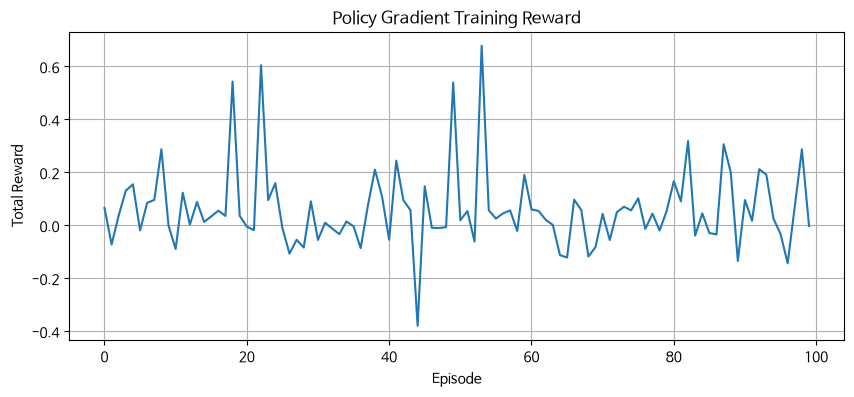

In [58]:
plt.figure(figsize=(10, 4))

plt.plot(
    episode_rewards
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title(
    "Policy Gradient Training Reward"
)

plt.grid()
plt.show()

In [59]:
# 그래프가 전반적으로 상승한다면 정책이 더 높은 Reward를 얻는 방향으로 학습되고 있다는 신호로 볼 수 있습니다. 
#     다만 강화학습에서는 Reward가 크게 오르내릴 수 있으므로 매 Episode가 계속 상승해야 하는 것은 아닙니다.

- 학습된 삼성전자 보유 확률 확인

In [60]:
policy_model.eval()

with torch.no_grad():

    test_states = torch.tensor(
        X[-10:],
        dtype=torch.float32
    )

    probabilities = (
        policy_model(test_states)
        .squeeze()
        .numpy()
    )

print("최근 10일 삼성전자 보유 확률")

for i, p in enumerate(probabilities):

    print(
        f"{i+1}일 : {p:.3f}"
    )

최근 10일 삼성전자 보유 확률
1일 : 0.599
2일 : 0.605
3일 : 0.605
4일 : 0.604
5일 : 0.598
6일 : 0.590
7일 : 0.601
8일 : 0.602
9일 : 0.593
10일 : 0.596


In [61]:
# 1일 : 0.547
# 현재 State에서 Policy Network가 삼성전자 보유(Action=1)에 약 54.7%의 확률을 부여했다는 의미입니다.

In [62]:
# DQN과 Policy Gradient의 차이
# DQN
# State
#   ↓
# [현금 Q값, 삼성전자 Q값]
#   ↓
# Q값이 큰 행동 선택


# Policy Gradient
# State
#   ↓
# Policy Network
#   ↓
# 삼성전자 보유 확률
#   ↓
# 확률에 따라 행동 선택

## 10회차. PPO + 삼성전자 백테스트

- Train 데이터 → PPO 학습 → Test 데이터 → Action 선택 → Reward → 누적수익률 → Buy & Hold전략과 성과비교

### 설치

In [81]:
%pip install stable-baselines3 gymnasium

Note: you may need to restart the kernel to use updated packages.


In [82]:
!pip install gymnasium stable-baselines3 -q

In [83]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

### 삼성전자 Trading Environment

In [84]:
class SamsungTradingEnv(gym.Env):

    def __init__(self, data):

        super().__init__()

        self.data = data.reset_index(
            drop=True
        )

        self.current_step = 0

        # 0 = 현금
        # 1 = 삼성전자 보유
        self.action_space = (
            spaces.Discrete(2)
        )

        self.observation_space = (
            spaces.Box(
                low=-np.inf,
                high=np.inf,
                shape=(3,),
                dtype=np.float32
            )
        )

        self.position = 0


    def get_state(self):

        row = self.data.iloc[
            self.current_step
        ]

        state = np.array(
            [
                row["수익률"],
                row["MA비율"],
                row["변동성5"]
            ],
            dtype=np.float32
        )

        return state


    def reset(
        self,
        seed=None,
        options=None
    ):

        super().reset(seed=seed)

        self.current_step = 0

        self.position = 0

        state = self.get_state()

        return state, {}


    def step(self, action):

        row = self.data.iloc[
            self.current_step
        ]

        next_return = (
            row["다음날수익률"]
        )

        # 거래비용
        transaction_cost = 0.001

        cost = (
            transaction_cost
            * abs(
                action
                - self.position
            )
        )

        reward = (
            action
            * next_return
            - cost
        )

        self.position = action

        self.current_step += 1

        terminated = (
            self.current_step
            >= len(self.data) - 1
        )

        truncated = False

        state = self.get_state()

        return (
            state,
            float(reward),
            terminated,
            truncated,
            {}
        )

### Train / Test 분할
- 여기에서 Random Split을 하지 않는 것이 중요합니다.

In [85]:
split = int(
    len(data) * 0.8
)

train_data = (
    data.iloc[:split]
    .copy()
)

test_data = (
    data.iloc[split:]
    .copy()
)

print(
    len(train_data),
    len(test_data)
)

1289 323


### PPO 학습

In [86]:
train_env = SamsungTradingEnv(
    train_data
)

model = PPO(
    "MlpPolicy",
    train_env,
    verbose=1
)

model.learn(
    total_timesteps=20000
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.29e+03 |
|    ep_rew_mean     | -0.435   |
| time/              |          |
|    fps             | 979      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.29e+03     |
|    ep_rew_mean          | -0.44        |
| time/                   |              |
|    fps                  | 805          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0052531897 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    en

### Test

In [87]:
test_env = SamsungTradingEnv(
    test_data
)

state, info = test_env.reset()

done = False

rewards = []
actions = []

while not done:

    action, _ = model.predict(
        state,
        deterministic=True
    )

    state, reward, terminated, truncated, info = (
        test_env.step(action)
    )

    rewards.append(reward)

    actions.append(int(action))

    done = (
        terminated
        or truncated
    )

- Test 결과 확인

In [88]:
print("테스트 거래일 수 :", len(rewards))
print("총 Reward :", sum(rewards))
print("평균 Reward :", np.mean(rewards))

print("\n처음 20개 Action")
print(actions[:20])

print("\n처음 20개 Reward")
print(rewards[:20])

테스트 거래일 수 : 322
총 Reward : 0.0
평균 Reward : 0.0

처음 20개 Action
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

처음 20개 Reward
[0.0, -0.0, -0.0, 0.0, 0.0, 0.0, 0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, 0.0]


- 삼성전자 보유 비율 확인

In [89]:
actions_array = np.array(actions)

cash_count = np.sum(actions_array == 0)
stock_count = np.sum(actions_array == 1)

print("현금 선택 횟수 :", cash_count)
print("삼성전자 선택 횟수 :", stock_count)

print(
    "삼성전자 보유 비율 :",
    stock_count / len(actions_array) * 100,
    "%"
)

현금 선택 횟수 : 322
삼성전자 선택 횟수 : 0
삼성전자 보유 비율 : 0.0 %


In [90]:
# PPO가 Test 기간 중 약 100%의 거래일에서 삼성전자 보유를 선택했다

### 누적수익률 계산

In [91]:
strategy_return = pd.Series(rewards)

strategy_cumulative = (
    1 + strategy_return
).cumprod() - 1

print(
    "PPO 최종 누적수익률 :",
    f"{strategy_cumulative.iloc[-1] * 100:.2f}%"
)

PPO 최종 누적수익률 : 0.00%


- 삼성전자 Buy & Hold와 비교합니다.
- Buy & Hold와 비교: 강화학습 투자에서는 PPO 수익률만 보는 것보다 삼성전자를 그냥 계속 보유했을 때와 비교하는 것이 중요

In [92]:
buy_hold_return = (
    test_data["다음날수익률"]
    .iloc[:len(rewards)]
    .reset_index(drop=True)
)

buy_hold_cumulative = (
    1 + buy_hold_return
).cumprod() - 1

print(
    "PPO 전략 :",
    f"{strategy_cumulative.iloc[-1] * 100:.2f}%"
)

print(
    "Buy & Hold :",
    f"{buy_hold_cumulative.iloc[-1] * 100:.2f}%"
)

PPO 전략 : 0.00%
Buy & Hold : 360.57%


- 그래프로 비교

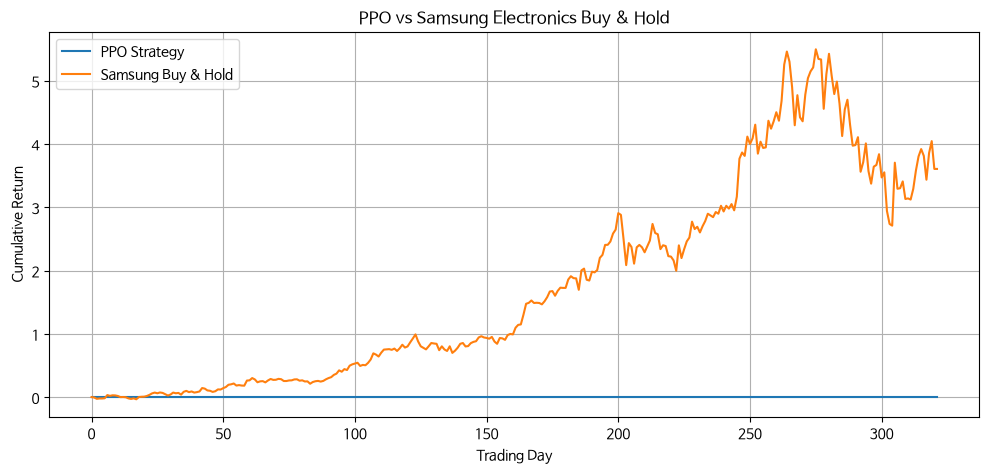

In [93]:
plt.figure(figsize=(12, 5))

plt.plot(
    strategy_cumulative,
    label="PPO Strategy"
)

plt.plot(
    buy_hold_cumulative,
    label="Samsung Buy & Hold"
)

plt.xlabel("Trading Day")
plt.ylabel("Cumulative Return")

plt.title(
    "PPO vs Samsung Electronics Buy & Hold"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
# 현재 State와 Reward 설정에서 PPO가 모든 Test 기간에 삼성전자 100% 보유 정책을 선택했으며, 
# 결과적으로 Buy & Hold와 거의 동일한 전략이 되었다. 입니다.
# 강화학습에서는 알고리즘만큼 State·Action·Reward 설계가 중요하다.

- 만약 현금 100%

In [95]:
print("현금 선택 :", actions.count(0))
print("주식 선택 :", actions.count(1))

print(
    "주식 보유비율 :",
    np.mean(actions) * 100,
    "%"
)

print(
    "PPO 최종 누적수익률 :",
    strategy_cumulative.iloc[-1] * 100,
    "%"
)

print(
    "Buy & Hold 최종 누적수익률 :",
    buy_hold_cumulative.iloc[-1] * 100,
    "%"
)

현금 선택 : 322
주식 선택 : 0
주식 보유비율 : 0.0 %
PPO 최종 누적수익률 : 0.0 %
Buy & Hold 최종 누적수익률 : 360.57347670250834 %


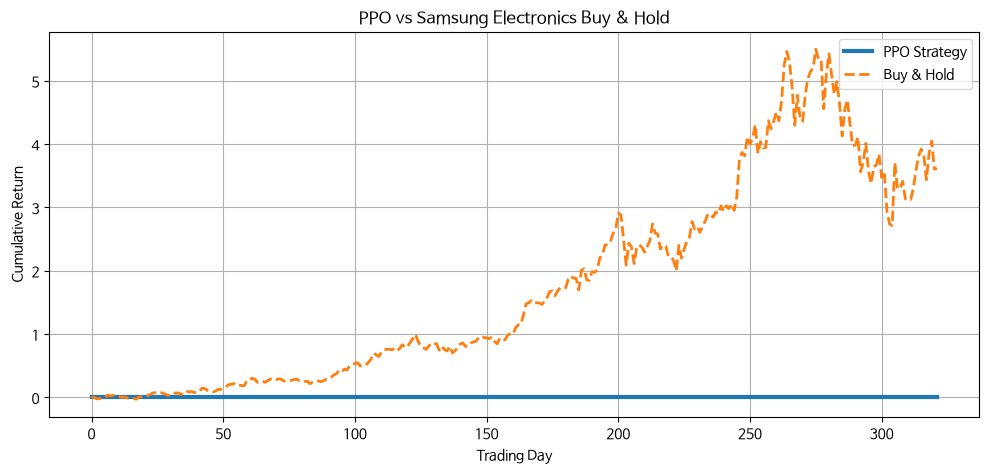

In [96]:
plt.figure(figsize=(12, 5))

plt.plot(
    strategy_cumulative,
    label="PPO Strategy",
    linewidth=3
)

plt.plot(
    buy_hold_cumulative,
    label="Buy & Hold",
    linewidth=2,
    linestyle="--"
)

plt.xlabel("Trading Day")
plt.ylabel("Cumulative Return")

plt.title(
    "PPO vs Samsung Electronics Buy & Hold"
)

plt.legend()
plt.grid()

plt.show()